### VLM Comparison Visualization

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

FILE_PATH = Path(r"D:\ibrand_superprototype\eval\comparison\vlm\vlm_final_result_annotations.xlsx")
REFERENCE_PATH = Path(r"D:\ibrand_superprototype\eval\vlm_reference_annotations_benchmark_final.xlsx")

df = pd.read_excel(FILE_PATH)

df.head()

,model,image_id,subject_accuracy,color_recall_count,unsupported_color_count,object_recall_count,unsupported_object_count
0,gemma,advan_laptop,1,3,1,3,0
1,gemma,aqua,0,3,1,3,0
2,gemma,axioo_pongo,1,2,1,3,0
3,gemma,batik_keris,0,4,1,1,1
4,gemma,bebek_pak_ndut,0,5,0,7,0


In [ ]:
df_2 = pd.read_excel(REFERENCE_PATH)

df_2.head()

,image_id,final_primary_subject,final_dominant_colors,final_objects
0,advan_laptop,laptop,"silver, black, blue","screen, keyboard, touchpad, laptop lid"
1,aqua,bottled water,"blue, green, transparent","mountain graphics, logo, bottle cap, bottle"
2,axioo_pongo,gaming laptop,"red, black","screen, keyboard, touchpad, monkey logo"
3,batik_keris,batik shirt,"navy blue, beige, gold, cream",person
4,bebek_pak_ndut,fried duck dish,"brown, black, red, white, green","chili, tofu, rice, fork, spoon, veggie, plate"


In [11]:
print(df_2.columns.tolist())

['image_id', 'final_primary_subject', 'final_dominant_colors', 'final_objects']


In [12]:
def count_items(value):
    if pd.isna(value):
        return 0
    
    items = [
        item.strip()
        for item in str(value).split(",")
        if item.strip()
    ]
    
    return len(items)

In [13]:
df_2["reference_object_count"] = df_2["final_objects"].apply(count_items)

In [17]:
df_2["reference_colour_count"] = df_2["final_dominant_colors"].apply(count_items)

In [19]:
df_2[
    [
        "image_id",
        "final_objects",
        "reference_object_count",
        "final_dominant_colors",
        "reference_colour_count"
    ]
].head()

,image_id,final_objects,reference_object_count,final_dominant_colors,reference_colour_count
0,advan_laptop,"screen, keyboard, touchpad, laptop lid",4,"silver, black, blue",3
1,aqua,"mountain graphics, logo, bottle cap, bottle",4,"blue, green, transparent",3
2,axioo_pongo,"screen, keyboard, touchpad, monkey logo",4,"red, black",2
3,batik_keris,person,1,"navy blue, beige, gold, cream",4
4,bebek_pak_ndut,"chili, tofu, rice, fork, spoon, veggie, plate",7,"brown, black, red, white, green",5


In [20]:
total_reference_objects = df_2["reference_object_count"].sum()
total_reference_colours = df_2["reference_colour_count"].sum()

print("Total reference objects:", total_reference_objects)
print("Total reference colours:", total_reference_colours)

Total reference objects: 63
Total reference colours: 56


In [21]:
reference_counts = df_2[
    [
        "image_id",
        "reference_object_count",
        "reference_colour_count"
    ]
]

In [22]:
df_merged = df.merge(
    reference_counts,
    on="image_id",
    how="left"
)

In [23]:
df_merged.head()

,model,image_id,subject_accuracy,color_recall_count,unsupported_color_count,object_recall_count,unsupported_object_count,reference_object_count,reference_colour_count
0,gemma,advan_laptop,1,3,1,3,0,4,3
1,gemma,aqua,0,3,1,3,0,4,3
2,gemma,axioo_pongo,1,2,1,3,0,4,2
3,gemma,batik_keris,0,4,1,1,1,1,4
4,gemma,bebek_pak_ndut,0,5,0,7,0,7,5


In [24]:
df_merged["object_reference_recall"] = (
    df_merged["object_recall_count"]
    / df_merged["reference_object_count"]
)

In [25]:
df_merged["colour_reference_recall"] = (
    df_merged["color_recall_count"]
    / df_merged["reference_colour_count"]
)

In [26]:
df_merged[
    [
        "model",
        "image_id",
        "object_recall_count",
        "reference_object_count",
        "object_reference_recall",
        "color_recall_count",
        "reference_colour_count",
        "colour_reference_recall"
    ]
].head()

,model,image_id,object_recall_count,reference_object_count,object_reference_recall,color_recall_count,reference_colour_count,colour_reference_recall
0,gemma,advan_laptop,3,4,0.75,3,3,1.0
1,gemma,aqua,3,4,0.75,3,3,1.0
2,gemma,axioo_pongo,3,4,0.75,2,2,1.0
3,gemma,batik_keris,1,1,1.00,4,4,1.0
4,gemma,bebek_pak_ndut,7,7,1.00,5,5,1.0


In [27]:
vlm_summary = (
    df_merged
    .groupby("model")
    .agg(
        subject_accuracy=("subject_accuracy", "mean"),
        object_reference_recall=("object_reference_recall", "mean"),
        colour_reference_recall=("colour_reference_recall", "mean"),
        mean_unsupported_objects=("unsupported_object_count", "mean"),
        mean_unsupported_colours=("unsupported_color_count", "mean"),
    )
    .reset_index()
)

In [28]:
vlm_summary["subject_accuracy"] *= 100
vlm_summary["object_reference_recall"] *= 100
vlm_summary["colour_reference_recall"] *= 100

vlm_summary.round(2)

,model,subject_accuracy,object_reference_recall,colour_reference_recall,mean_unsupported_objects,mean_unsupported_colours
0,gemma,50.00,92.59,97.50,0.28,0.67
1,kimi,66.67,74.01,86.48,0.50,0.61
2,qwen,83.33,94.84,92.96,0.17,0.33


In [ ]:
plot_df = vlm_summary.copy()

plot_df

,model,subject_accuracy,object_reference_recall,colour_reference_recall,mean_unsupported_objects,mean_unsupported_colours
0,gemma,50.000000,92.592593,97.500000,0.277778,0.666667
1,kimi,66.666667,74.007937,86.481481,0.500000,0.611111
2,qwen,83.333333,94.841270,92.962963,0.166667,0.333333


In [35]:
model_name_map = {
    "gemma": "gemma-3-12b-it",
    "kimi": "moonshot-v1-32k-vision-preview",
    "qwen": "qwen3-vl-8b-instruct"
}

plot_df["model"] = plot_df["model"].replace(model_name_map)

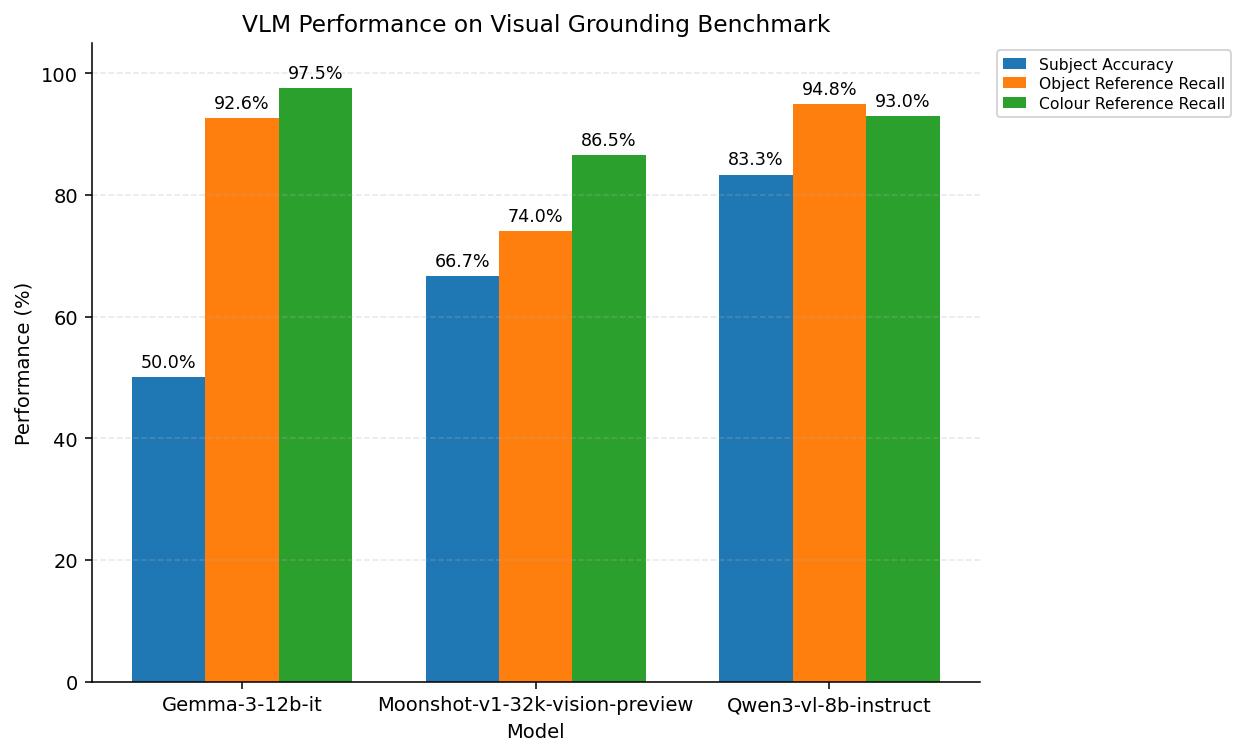

In [36]:
import numpy as np

models = plot_df["model"].str.capitalize()

subject = plot_df["subject_accuracy"]
objects = plot_df["object_reference_recall"]
colours = plot_df["colour_reference_recall"]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5.5))

bars1 = ax.bar(
    x - width,
    subject,
    width,
    label="Subject Accuracy"
)

bars2 = ax.bar(
    x,
    objects,
    width,
    label="Object Reference Recall"
)

bars3 = ax.bar(
    x + width,
    colours,
    width,
    label="Colour Reference Recall"
)

ax.set_title("VLM Performance on Visual Grounding Benchmark")
ax.set_xlabel("Model")
ax.set_ylabel("Performance (%)")

ax.set_xticks(x)
ax.set_xticklabels(models)

ax.set_ylim(0, 105)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    fontsize=8,
    frameon=True,
    handlelength=1.5,
    borderpad=0.4,
    labelspacing=0.3
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

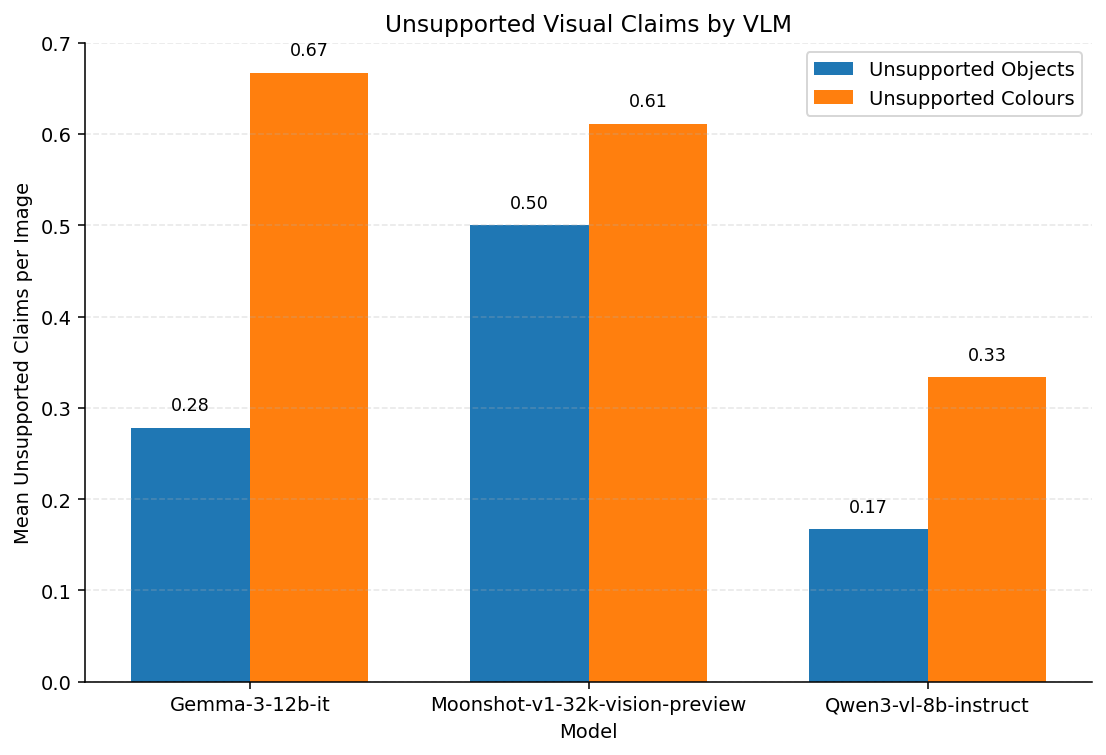

In [37]:
unsupported_objects = plot_df["mean_unsupported_objects"]
unsupported_colours = plot_df["mean_unsupported_colours"]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5.5))

bars1 = ax.bar(
    x - width / 2,
    unsupported_objects,
    width,
    label="Unsupported Objects"
)

bars2 = ax.bar(
    x + width / 2,
    unsupported_colours,
    width,
    label="Unsupported Colours"
)

ax.set_title("Unsupported Visual Claims by VLM")
ax.set_xlabel("Model")
ax.set_ylabel("Mean Unsupported Claims per Image")

ax.set_xticks(x)
ax.set_xticklabels(models)

ax.legend()

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.015,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()